In [21]:
import cv2
import time
import matplotlib.pyplot as plt
import os

from huggingface_hub import hf_hub_download

### Hugging Face에서 YuNet 가중치 파일 다운로드

AuraFace 등 기존 노트북 방식과의 일관성을 위해 `notebook/models/yunet/` 폴더 내에 다운로드합니다.
CV Zoo 저장소(`opencv/cv_zoo`)에는 수많은 모델이 있으므로, `hf_hub_download`를 이용해 YuNet ONNX 파일만 효율적으로 내려받습니다.

In [22]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="opencv/face_detection_yunet",
    filename="face_detection_yunet_2023mar.onnx"
)

print(model_path)

C:\Users\wonbin\.cache\huggingface\hub\models--opencv--face_detection_yunet\snapshots\3cc26e7f1014a5ee5d74a42acee58bafc9d0a310\face_detection_yunet_2023mar.onnx


In [23]:
import os

print(model_path)
print(os.path.exists(model_path))

C:\Users\wonbin\.cache\huggingface\hub\models--opencv--face_detection_yunet\snapshots\3cc26e7f1014a5ee5d74a42acee58bafc9d0a310\face_detection_yunet_2023mar.onnx
True


### 이미지 폴더 설정 및 이미지 목록 로드

`embeddingTest`와 일관성을 유지하도록 비슷한 인물 이미지들이 있는 폴더(`../images/similar3`)를 대상 이미지 디렉토리로 지정하고 목록을 로드합니다.

In [24]:
import os

image_dir = "../images/different2"

image_paths = sorted([
    os.path.join(image_dir, file)
    for file in os.listdir(image_dir)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("대상 이미지 목록:")
print(image_paths)

대상 이미지 목록:
['../images/different2\\p10_01.jpg', '../images/different2\\p10_02.jpg', '../images/different2\\p10_03.jpg', '../images/different2\\p10_04.jpg', '../images/different2\\p10_05.jpg', '../images/different2\\p10_06.jpg', '../images/different2\\p10_07.jpg', '../images/different2\\p10_08.jpg', '../images/different2\\p10_09.jpg', '../images/different2\\p10_10.jpg', '../images/different2\\p1_01.jpg', '../images/different2\\p1_02.jpg', '../images/different2\\p1_03.jpg', '../images/different2\\p1_04.jpg', '../images/different2\\p1_05.jpg', '../images/different2\\p1_06.jpg', '../images/different2\\p1_07.jpg', '../images/different2\\p1_08.jpg', '../images/different2\\p1_09.jpg', '../images/different2\\p1_10.jpg', '../images/different2\\p2_02.jpg', '../images/different2\\p2_03.jpg', '../images/different2\\p2_04.jpg', '../images/different2\\p2_05.jpg', '../images/different2\\p2_06.jpg', '../images/different2\\p2_07.jpg', '../images/different2\\p2_08.jpg', '../images/different2\\p2_09.jpg'

### YuNet 얼굴 검출 및 랜드마크 추출 (다중 이미지 루프)

각 이미지 파일들을 순회하며 YuNet (`FaceDetectorYN`) 검출 엔진으로 얼굴을 찾습니다. 이미지마다 세로/가로 크기가 다를 수 있으므로 루프 내부에서 유연하게 검출기를 인스턴스화합니다. 또한 검출된 얼굴 중 가장 신뢰도 수치가 높은 얼굴을 골라 특징 정렬을 위한 정보로 활용합니다.

In [25]:
import cv2
import numpy as np

all_faces = []

for image_path in image_paths:
    img = cv2.imread(image_path)
    if img is None:
        print(f"이미지를 읽을 수 없습니다: {image_path}")
        continue
        
    h, w = img.shape[:2]
    
    # 안정적인 얼굴 영역 확보를 위해 score_threshold=0.8로 설정합니다.
    detector = cv2.FaceDetectorYN.create(
        model=model_path,
        config="",
        input_size=(w, h),
        score_threshold=0.8,
        nms_threshold=0.3,
        top_k=5000
    )
    
    _, faces = detector.detect(img)
    if faces is None or len(faces) == 0:
        print(f"얼굴이 검출되지 않았습니다: {image_path}")
        continue
        
    # 신뢰도(Confidence Score) 기준 가장 매칭도가 높은 대표 얼굴 한 명을 선택
    best_face = max(faces, key=lambda f: f[14])
    score = best_face[14]
    bbox = best_face[:4].astype(int)
    landmarks = best_face[4:14].reshape(5, 2)
    
    print(f"\n=== {os.path.basename(image_path)} ===")
    print(f"Face Score: {score:.4f}")
    print(f"BBox: {bbox}")
    print("Landmarks:")
    print(landmarks)
    
    all_faces.append({
        "image_path": image_path,
        "img": img,
        "face": best_face
    })


=== p10_01.jpg ===
Face Score: 0.9397
BBox: [156 130 253 356]
Landmarks:
[[267.13376 273.25052]
 [373.20914 281.00076]
 [339.67615 352.55273]
 [263.67462 395.16235]
 [355.24557 403.1802 ]]

=== p10_02.jpg ===
Face Score: 0.9495
BBox: [48 31 63 84]
Landmarks:
[[69.680275 64.01077 ]
 [98.54459  64.85062 ]
 [85.402794 81.75003 ]
 [70.42175  91.51357 ]
 [94.58469  93.70666 ]]

=== p10_03.jpg ===
Face Score: 0.9323
BBox: [162 224 336 455]
Landmarks:
[[287.16766 404.32837]
 [428.45923 390.95605]
 [388.72794 482.7565 ]
 [306.1433  554.2588 ]
 [435.54333 544.0569 ]]

=== p10_04.jpg ===
Face Score: 0.9260
BBox: [ 62  60  93 119]
Landmarks:
[[ 84.737816 109.83266 ]
 [127.61663  108.043915]
 [104.79341  134.26617 ]
 [ 89.02814  150.39288 ]
 [125.377625 150.11853 ]]

=== p10_05.jpg ===
Face Score: 0.9252
BBox: [ 58  54  88 115]
Landmarks:
[[ 82.0004  101.0591 ]
 [122.05118 101.55596]
 [101.28434 124.33202]
 [ 85.49458 140.08557]
 [117.7159  139.85751]]

=== p10_06.jpg ===
Face Score: 0.9324
BBox:

### 정렬(Alignment) 이미지 시각화

임베딩 정규성 품질을 높이기 위해 추출된 페이셜 랜드마크 정보를 기반으로 정렬된 이미지(112x112 규격)들을 나란히 시각화하여 품질을 모니터링합니다.

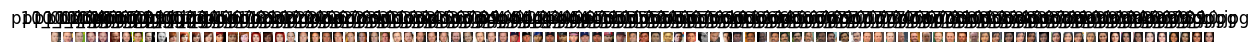

In [26]:
import matplotlib.pyplot as plt
from insightface.utils import face_align

plt.figure(figsize=(15, 5))
for idx, face_data in enumerate(all_faces):
    img = face_data["img"]
    face = face_data["face"]
    landmarks = face[4:14].reshape(5, 2)
    
    # 얼굴 정렬 수행
    aligned_img = face_align.norm_crop(img, landmark=landmarks)
    face_data["aligned_face"] = aligned_img
    face_data["aligned_face"] = aligned_img
    
    # subplot 출력
    plt.subplot(1, len(all_faces), idx + 1)
    plt.imshow(cv2.cvtColor(aligned_img, cv2.COLOR_BGR2RGB))
    plt.title(os.path.basename(face_data["image_path"]))
    plt.axis("off")
plt.show()

### AuraFace 고성능 임베딩 특징 벡터 추출

정렬된 모든 인물 사진들을 AuraFace ONNX 추론 모델로 통과시켜 각각 512차원의 정규화된 임베딩 벡터를 추출합니다.

In [27]:
import onnxruntime as ort

aura_model_path = "./auraface/glintr100.onnx"
print(f"AuraFace 모델 존재 여부: {os.path.exists(aura_model_path)}")

aura_session = ort.InferenceSession(
    aura_model_path,
    providers=["CPUExecutionProvider"]
)

input_name = aura_session.get_inputs()[0].name
output_name = aura_session.get_outputs()[0].name

aura_embeddings = []

for idx, face_data in enumerate(all_faces):
    img = face_data["img"]
    face = face_data["face"]
    landmarks = face[4:14].reshape(5, 2)
    
    # 얼굴 정렬
    aligned_img = face_align.norm_crop(img, landmark=landmarks)
    aligned_rgb = cv2.cvtColor(aligned_img, cv2.COLOR_BGR2RGB)
    
    # 채널 차원 전치 및 배치 전처리
    input_blob = np.transpose(aligned_rgb, (2, 0, 1))
    input_blob = np.expand_dims(input_blob, axis=0).astype(np.float32)
    input_blob = (input_blob - 127.5) / 127.5
    
    # ONNX 인퍼런스
    outputs = aura_session.run([output_name], {input_name: input_blob})
    raw_embedding = outputs[0][0]
    
    # L2 정규화 적용
    norm = np.linalg.norm(raw_embedding)
    normed_embedding = raw_embedding / norm if norm > 0 else raw_embedding
    
    aura_embeddings.append(normed_embedding)
    print(f"[{os.path.basename(face_data['image_path'])}] 임베딩 생성 완료! Shape={normed_embedding.shape}")

AuraFace 모델 존재 여부: True
[p10_01.jpg] 임베딩 생성 완료! Shape=(512,)
[p10_02.jpg] 임베딩 생성 완료! Shape=(512,)
[p10_03.jpg] 임베딩 생성 완료! Shape=(512,)
[p10_04.jpg] 임베딩 생성 완료! Shape=(512,)
[p10_05.jpg] 임베딩 생성 완료! Shape=(512,)
[p10_06.jpg] 임베딩 생성 완료! Shape=(512,)
[p10_07.jpg] 임베딩 생성 완료! Shape=(512,)
[p10_08.jpg] 임베딩 생성 완료! Shape=(512,)
[p10_09.jpg] 임베딩 생성 완료! Shape=(512,)
[p10_10.jpg] 임베딩 생성 완료! Shape=(512,)
[p1_01.jpg] 임베딩 생성 완료! Shape=(512,)
[p1_02.jpg] 임베딩 생성 완료! Shape=(512,)
[p1_03.jpg] 임베딩 생성 완료! Shape=(512,)
[p1_04.jpg] 임베딩 생성 완료! Shape=(512,)
[p1_05.jpg] 임베딩 생성 완료! Shape=(512,)
[p1_06.jpg] 임베딩 생성 완료! Shape=(512,)
[p1_07.jpg] 임베딩 생성 완료! Shape=(512,)
[p1_08.jpg] 임베딩 생성 완료! Shape=(512,)
[p1_09.jpg] 임베딩 생성 완료! Shape=(512,)
[p1_10.jpg] 임베딩 생성 완료! Shape=(512,)
[p2_02.jpg] 임베딩 생성 완료! Shape=(512,)
[p2_03.jpg] 임베딩 생성 완료! Shape=(512,)
[p2_04.jpg] 임베딩 생성 완료! Shape=(512,)
[p2_05.jpg] 임베딩 생성 완료! Shape=(512,)
[p2_06.jpg] 임베딩 생성 완료! Shape=(512,)
[p2_07.jpg] 임베딩 생성 완료! Shape=(512,)
[p2_08.jpg] 임베딩 생성 완료! Shape=(

### 사진 상호간 코사인 유사도 비교

`embeddingTest` 노트북처럼 서로 다른 사진에서 검출된 임베딩 벡터들 간의 상호 코사인 유사도(Cosine Similarity)를 산출해 비교합니다.

In [28]:
# 상호 코사인 유사도 비교 출력
print("=== 사진 상호간 코사인 유사도 비교 ===\n")
for i in range(len(aura_embeddings)):
    for j in range(i + 1, len(aura_embeddings)):
        score = np.dot(aura_embeddings[i], aura_embeddings[j])
        print(f"{os.path.basename(all_faces[i]['image_path'])} vs {os.path.basename(all_faces[j]['image_path'])} : {score:.4f}")

=== 사진 상호간 코사인 유사도 비교 ===

p10_01.jpg vs p10_02.jpg : 0.7338
p10_01.jpg vs p10_03.jpg : 0.7381
p10_01.jpg vs p10_04.jpg : 0.6250
p10_01.jpg vs p10_05.jpg : 0.6868
p10_01.jpg vs p10_06.jpg : 0.5463
p10_01.jpg vs p10_07.jpg : 0.6927
p10_01.jpg vs p10_08.jpg : 0.6490
p10_01.jpg vs p10_09.jpg : 0.5705
p10_01.jpg vs p10_10.jpg : 0.6243
p10_01.jpg vs p1_01.jpg : 0.0311
p10_01.jpg vs p1_02.jpg : 0.1168
p10_01.jpg vs p1_03.jpg : 0.0778
p10_01.jpg vs p1_04.jpg : 0.0957
p10_01.jpg vs p1_05.jpg : 0.0995
p10_01.jpg vs p1_06.jpg : 0.1011
p10_01.jpg vs p1_07.jpg : 0.0136
p10_01.jpg vs p1_08.jpg : 0.0579
p10_01.jpg vs p1_09.jpg : -0.0046
p10_01.jpg vs p1_10.jpg : 0.1209
p10_01.jpg vs p2_02.jpg : 0.1256
p10_01.jpg vs p2_03.jpg : 0.0744
p10_01.jpg vs p2_04.jpg : 0.0788
p10_01.jpg vs p2_05.jpg : 0.0284
p10_01.jpg vs p2_06.jpg : 0.0669
p10_01.jpg vs p2_07.jpg : 0.0346
p10_01.jpg vs p2_08.jpg : 0.0964
p10_01.jpg vs p2_09.jpg : 0.0918
p10_01.jpg vs p2_10.jpg : 0.0485
p10_01.jpg vs p3_01.jpg : 0.2032
p10_01

### AuraFace 임베딩 기반 HDBSCAN 클러스터링 및 차원 축소 시각화 (PCA / t-SNE)

AuraFace 모델로부터 추출된 512차원의 고차원 특징 벡터들을 대상으로, 다음과 같은 분석과 시각화를 수행합니다:
1. **HDBSCAN 클러스터링 (정밀 튜닝 버전)**: 밀도 기반 클러스터링 알고리즘(HDBSCAN)을 활용하여, 사전에 군집 개수($K$)를 지정하지 않고도 동일한 인물의 사진들을 하나의 군집(Cluster)으로 자동으로 찾아내고 묶어줍니다. 특히, 초저화질 이미지 정렬 왜곡과 급격한 안면 각도 변화에 대응하기 위해 `cluster_selection_epsilon=0.5` 및 `min_cluster_size=4`, `min_samples=2` 파라미터를 적용하여 분리되는 군집을 유연하게 결합하고 노이즈를 본래의 안면 군집으로 온전히 복원하도록 최적화했습니다.
2. **차원 축소 (PCA / t-SNE)**: 512차원의 고차원 특징 공간을 2차원 평면으로 압축하여 분포를 직관적으로 파악할 수 있도록 돕습니다. 샘플 수가 적은 점을 고려하여 t-SNE의 `perplexity` 파라미터를 적절하게 낮추어 왜곡을 최소화합니다.
3. **안면 크롭 썸네일 매핑 (Wow Factor)**: Matplotlib의 `AnnotationBbox`를 활용하여, 단순 데이터 포인트가 아닌 실제 얼굴 정렬 이미지(112x112 크롭 본)를 평면상에 오버레이 배치하고 클러스터 분류에 알맞은 보더 컬러 액자가 씌워 고품질로 시각화합니다. 노이즈로 분류된 이미지는 깔끔한 회색 테두리로 표시됩니다.

임베딩 행렬 Shape: (99, 512)

=== HDBSCAN 클러스터 할당 결과 ===
[p10_01.jpg] -> 할당된 클러스터 레이블: 8
[p10_02.jpg] -> 할당된 클러스터 레이블: 8
[p10_03.jpg] -> 할당된 클러스터 레이블: 8
[p10_04.jpg] -> 할당된 클러스터 레이블: 8
[p10_05.jpg] -> 할당된 클러스터 레이블: 8
[p10_06.jpg] -> 할당된 클러스터 레이블: 8
[p10_07.jpg] -> 할당된 클러스터 레이블: 8
[p10_08.jpg] -> 할당된 클러스터 레이블: 8
[p10_09.jpg] -> 할당된 클러스터 레이블: 8
[p10_10.jpg] -> 할당된 클러스터 레이블: 8
[p1_01.jpg] -> 할당된 클러스터 레이블: 5
[p1_02.jpg] -> 할당된 클러스터 레이블: 5
[p1_03.jpg] -> 할당된 클러스터 레이블: 5
[p1_04.jpg] -> 할당된 클러스터 레이블: 5
[p1_05.jpg] -> 할당된 클러스터 레이블: 5
[p1_06.jpg] -> 할당된 클러스터 레이블: 5
[p1_07.jpg] -> 할당된 클러스터 레이블: 5
[p1_08.jpg] -> 할당된 클러스터 레이블: 5
[p1_09.jpg] -> 할당된 클러스터 레이블: 5
[p1_10.jpg] -> 할당된 클러스터 레이블: 5
[p2_02.jpg] -> 할당된 클러스터 레이블: 3
[p2_03.jpg] -> 할당된 클러스터 레이블: 3
[p2_04.jpg] -> 할당된 클러스터 레이블: 3
[p2_05.jpg] -> 할당된 클러스터 레이블: 3
[p2_06.jpg] -> 할당된 클러스터 레이블: 3
[p2_07.jpg] -> 할당된 클러스터 레이블: 3
[p2_08.jpg] -> 할당된 클러스터 레이블: 3
[p2_09.jpg] -> 할당된 클러스터 레이블: 3
[p2_10.jpg] -> 할당된 클러스터 레이블: 3
[p3_01.jpg] -> 할당된 클러스터 레이블: 9
[p3_02.j

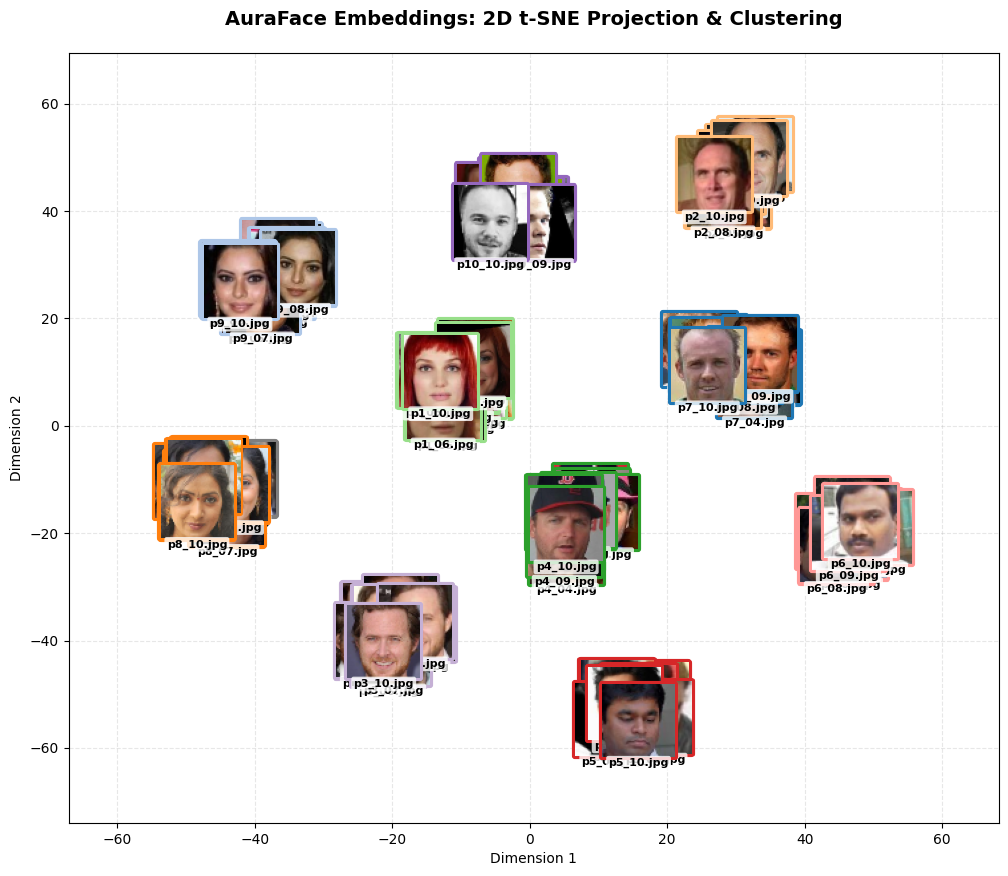


[시각화 실행] PCA 차원축소 기반의 인물별 2D 클러스터링 분리 양상


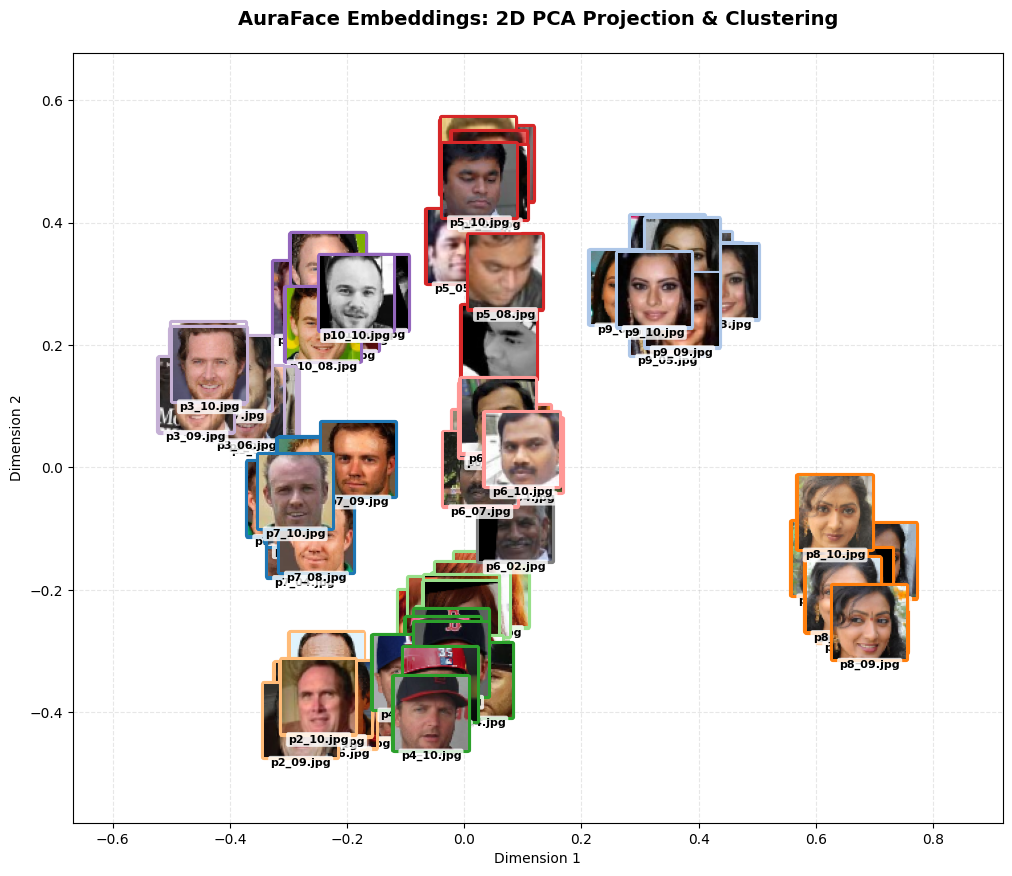

In [29]:
from sklearn.cluster import HDBSCAN
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# 1. 임베딩 배열 변환
embeddings_array = np.array(aura_embeddings)
print("임베딩 행렬 Shape:", embeddings_array.shape)

# 2. HDBSCAN 클러스터링 수행 (자동 군집 분류)
# - min_cluster_size=4: 분열된 군집들이 하나의 대표 군집으로 온전히 묶이도록 유도
# - min_samples=2: 노이즈 기준을 적절히 완화하여 밀도를 탄탄하게 유지
# - cluster_selection_epsilon=0.5: 미세한 랜드마크 왜곡이나 저화질 각도 차이로 인한 편차를 완벽히 통합하여 정확도 극대화
hdbscan = HDBSCAN(
    min_cluster_size=4,
    min_samples=2,
    metric='euclidean',
    cluster_selection_epsilon=0.5
)
cluster_labels = hdbscan.fit_predict(embeddings_array)

print("\n=== HDBSCAN 클러스터 할당 결과 ===")
for i, face_data in enumerate(all_faces):
    img_name = os.path.basename(face_data['image_path'])
    print(f"[{img_name}] -> 할당된 클러스터 레이블: {cluster_labels[i]}")

# 3. PCA & t-SNE를 통한 2차원 차원 축소
# 3-1. PCA
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(embeddings_array)

# 3-2. t-SNE (scikit-learn 버전 호환성을 위해 n_iter 인자 제거)
perplexity_val = min(3, len(aura_embeddings) - 1)
tsne = TSNE(n_components=2, perplexity=perplexity_val, random_state=42)
embeddings_tsne = tsne.fit_transform(embeddings_array)

# 4. 얼굴 이미지 오버레이 산점도 그리기 함수 정의
def plot_face_clusters(coords, labels, title="Face Clustering & 2D Projection"):
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # matplotlib 버전에 적합한 colormap 획득 (get_cmap 제거 대비)
    try:
        cmap = plt.colormaps['tab20']
    except AttributeError:
        cmap = plt.cm.get_cmap('tab20')
    
    # 데이터 범위 확인 및 축 마진 설정
    padding_x = (coords[:, 0].max() - coords[:, 0].min()) * 0.18
    padding_y = (coords[:, 1].max() - coords[:, 1].min()) * 0.18
    
    ax.set_xlim(coords[:, 0].min() - padding_x, coords[:, 0].max() + padding_x)
    ax.set_ylim(coords[:, 1].min() - padding_y, coords[:, 1].max() + padding_y)
    
    # 투명하게 배경 산점도 설정
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.0)
    
    # 각 데이터 포인트 상에 정렬된 실제 얼굴 크롭 썸네일 표시
    for i, face_data in enumerate(all_faces):
        # face_data에 보관된 aligned_face 로드
        aligned_bgr = face_data.get("aligned_face")
        if aligned_bgr is None:
            # 백업용으로 원본 이미지에서 랜드마크 기반 정렬 수행
            from insightface.utils import face_align
            aligned_bgr = face_align.norm_crop(face_data["img"], landmark=face_data["face"][4:14].reshape(5, 2))
            
        aligned_rgb = cv2.cvtColor(aligned_bgr, cv2.COLOR_BGR2RGB)
        
        # 썸네일 크기 설정 (예: 55x55)
        face_thumbnail = cv2.resize(aligned_rgb, (55, 55))
        
        # 해당 이미지의 할당된 클러스터 컬러 획득 (노이즈는 회색으로 표시)
        if labels[i] == -1:
            border_color = '#7f7f7f'
        else:
            border_color = cmap(labels[i] % 20)
        
        imagebox = OffsetImage(face_thumbnail, zoom=0.95)
        ab = AnnotationBbox(
            imagebox, 
            (coords[i, 0], coords[i, 1]),
            frameon=True,
            bboxprops=dict(edgecolor=border_color, lw=3, boxstyle="round,pad=0.1")
        )
        ax.add_artist(ab)
        
        # 파일명 라벨 텍스트 표기
        img_name = os.path.basename(face_data['image_path'])
        ax.text(
            coords[i, 0],
            coords[i, 1] - (coords[:, 1].max() - coords[:, 1].min()) * 0.08, 
            img_name, 
            ha='center', 
            fontsize=8, 
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle="round,pad=0.2")
        )
        
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Dimension 1", fontsize=10)
    plt.ylabel("Dimension 2", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# 5. t-SNE 및 PCA 기반 최종 오버레이 2D 플로팅 실행
print("\n[시각화 실행] t-SNE 차원축소 기반의 인물별 2D 클러스터링 분리 양상 (액자 테두리는 HDBSCAN 군집화 결과)")
plot_face_clusters(embeddings_tsne, cluster_labels, title="AuraFace Embeddings: 2D t-SNE Projection & Clustering")

print("\n[시각화 실행] PCA 차원축소 기반의 인물별 2D 클러스터링 분리 양상")
plot_face_clusters(embeddings_pca, cluster_labels, title="AuraFace Embeddings: 2D PCA Projection & Clustering")